# SARSA

In [2]:
from IPython.display import Video
import gymnasium as gym
from IPython.display import display
from typing import Optional
import warnings
import numpy as np
from tqdm import tqdm
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore",category=DeprecationWarning)

In [3]:
class SarsaAgent:
    def __init__(self,env,gamma=1.0, alpha=0.05, epsilon=0.1):
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.env = env
        self.q = np.zeros((env.observation_space.n, env.action_space.n))
        self.train()

    def get_random_action(self):
        return self.env.action_space.sample()

    def get_best_action(self, state):
        return np.argmax(self.q[state])
    
    def get_epsilon_greedy_action(self, state):
        if np.random.rand() < self.epsilon:
            return self.get_random_action()
        return self.get_best_action(state)
    

    def train(self, num_episodes=100000):
        for i in tqdm(range(num_episodes)):
            state,_ = self.env.reset()
            action = self.get_epsilon_greedy_action(state)
            done = False
            while not done:
                next_state, reward, done, _, _ = self.env.step(action)
                next_action = self.get_epsilon_greedy_action(next_state)
                self.q[state, action] += self.alpha * (reward + self.gamma * self.q[next_state, next_action] - self.q[state, action])
                state = next_state
                action = next_action
    

In [7]:
env = gym.make('CliffWalking-v0', render_mode="rgb_array")
agent = SarsaAgent(env)

100%|██████████| 100000/100000 [00:18<00:00, 5534.88it/s]


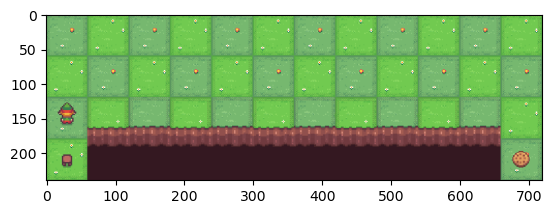

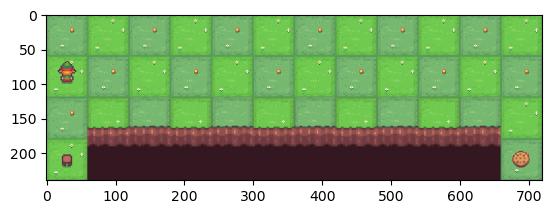

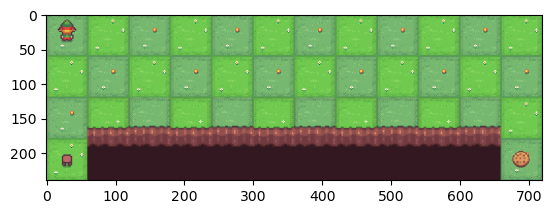

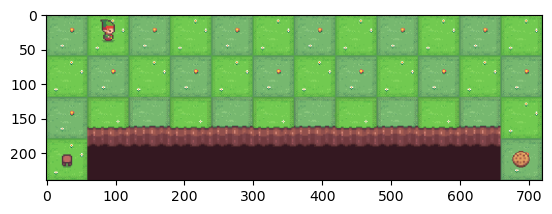

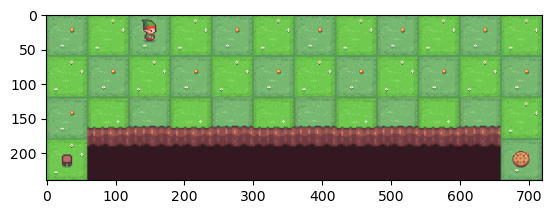

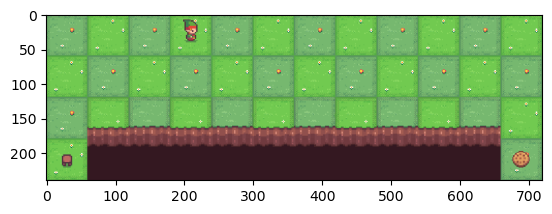

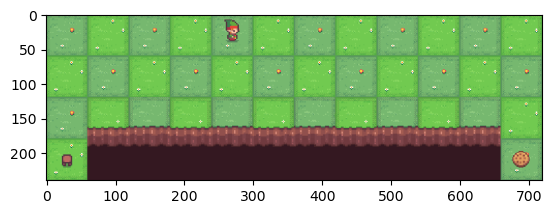

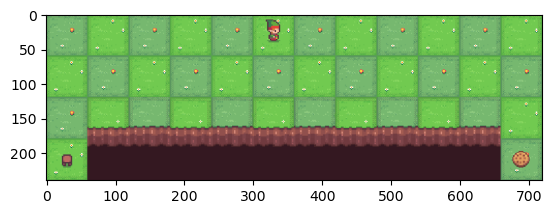

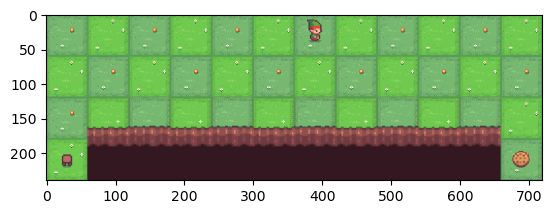

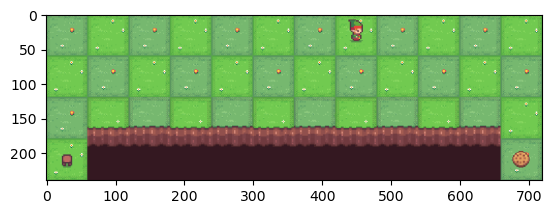

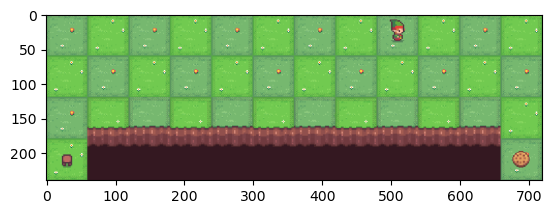

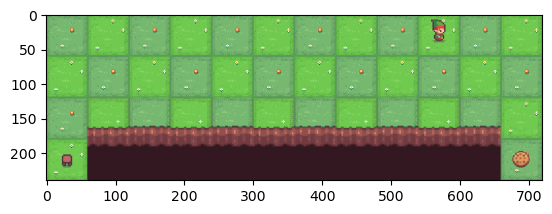

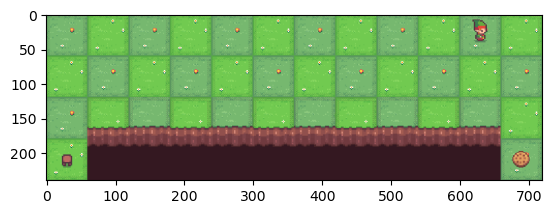

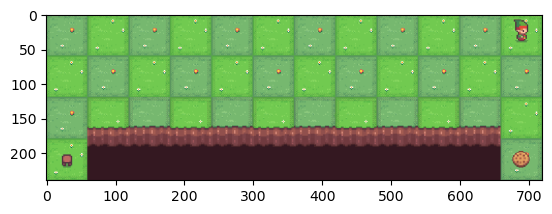

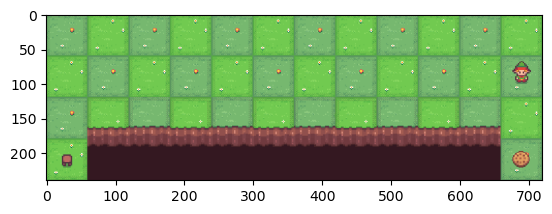

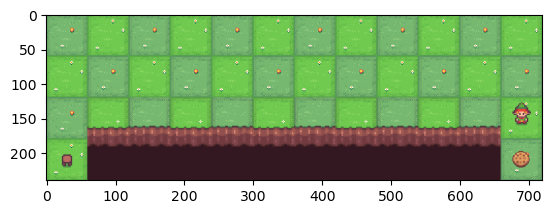

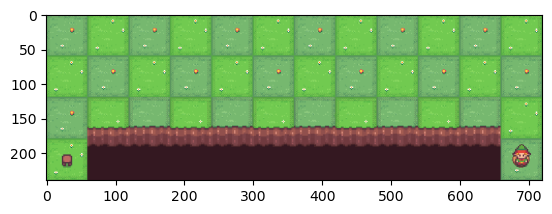

In [19]:
def step_by_step(env, agent, num_episodes=1):
    for i in range(num_episodes):
        state, _ = env.reset()
        done = False
        while not done:
            action = agent.get_best_action(state)
            next_state, _, done, _, _ = env.step(action)
            plt.imshow(env.render())
            plt.show()
            state = next_state

step_by_step(env, agent, num_episodes=1)


# Q-Learning

In [20]:
class QAgent:
    def __init__(self,env,gamma=1.0, alpha=0.05, epsilon=0.1):
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.env = env
        self.q = np.zeros((env.observation_space.n, env.action_space.n))
        self.train()

    def get_random_action(self):
        return self.env.action_space.sample()

    def get_best_action(self, state):
        return np.argmax(self.q[state])
    
    def get_epsilon_greedy_action(self, state):
        if np.random.rand() < self.epsilon:
            return self.get_random_action()
        return self.get_best_action(state)
    

    def train(self, num_episodes=100000):
        for i in tqdm(range(num_episodes)):
            state,_ = self.env.reset()
            done = False
            while not done:
                action = self.get_epsilon_greedy_action(state)
                next_state, reward, done, _, _ = self.env.step(action)
                max_q = np.max(self.q[next_state])
                self.q[state, action] += self.alpha * (reward + self.gamma * max_q - self.q[state, action])
                state = next_state
    

In [21]:
env = gym.make('CliffWalking-v0', render_mode="rgb_array")
agent = QAgent(env)

100%|██████████| 100000/100000 [00:22<00:00, 4412.08it/s]


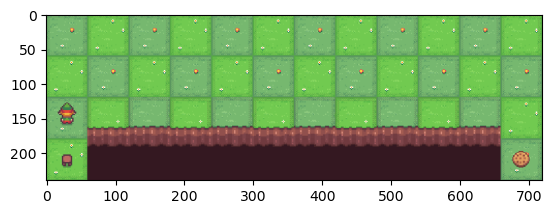

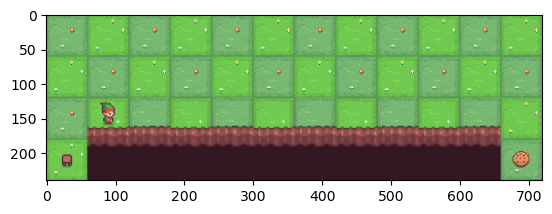

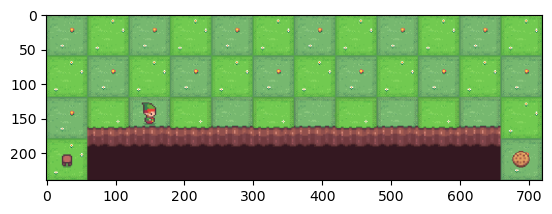

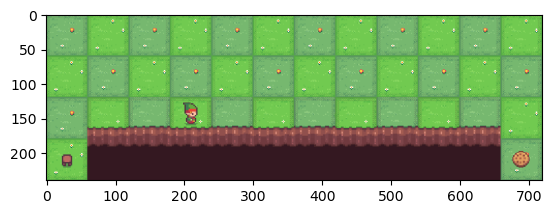

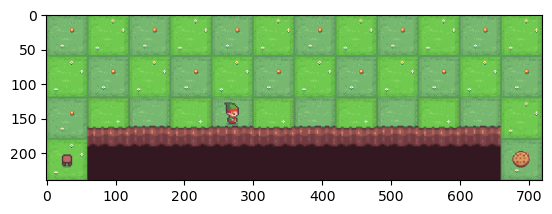

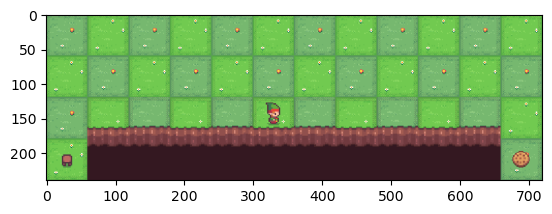

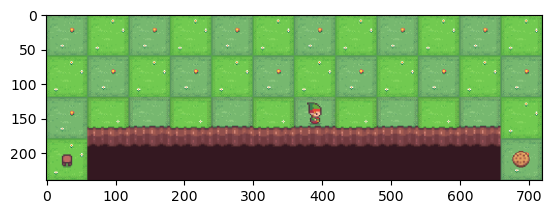

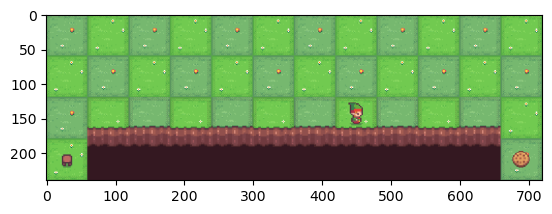

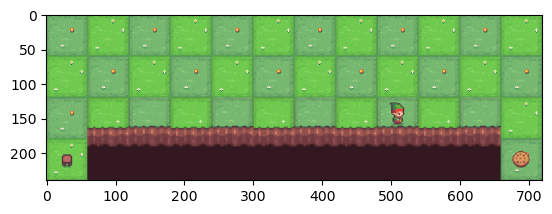

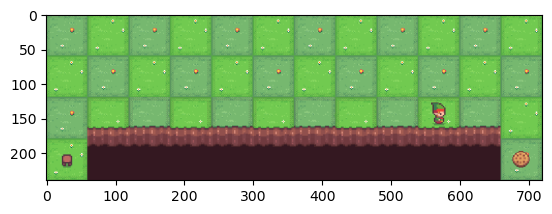

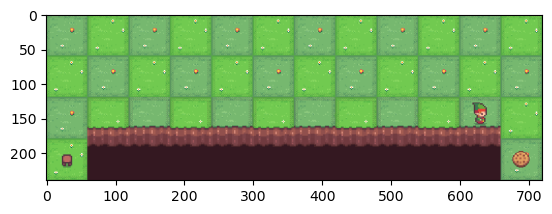

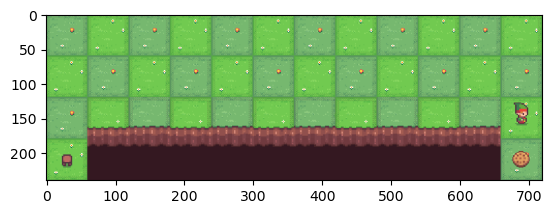

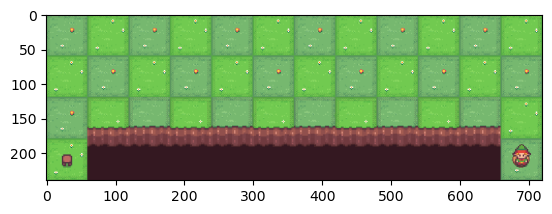

In [22]:
step_by_step(env, agent, num_episodes=1)